# CACE-SOG cumulene evaluation

This notebook mirrors the logic in `metrics_cumulene.py` and `results_cumulene.py` for the CACE-SOG model.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
from ase.io import read
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
%env PYTHONPATH=/data/home/public/qiuqizhi/SOG-Qeq/SOG-Net/CACE-SOG-Ji

env: PYTHONPATH=/data/home/public/qiuqizhi/SOG-Qeq/SOG-Net/CACE-SOG-Ji


In [3]:
# Paths
WORKDIR = Path("/data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/CACE-SOG")
DATASET_DIR = Path("/data/home/public/qiuqizhi/LOREM/datasets")
MODEL_PATH = WORKDIR / "best_model-out3.pth"
CACE_REPO = Path("/data/home/public/qiuqizhi/SOG-Qeq/SOG-Net/CACE-SOG-Ji")
CACE_BUILD_LIB = CACE_REPO / "build/lib"

# Prefer source package; fallback to build/lib when source is incomplete.
if str(CACE_REPO) not in sys.path:
    sys.path.insert(0, str(CACE_REPO))

try:
    from cace.calculators import CACECalculator
except ModuleNotFoundError as exc:
    if "cace.data.atomic_data" not in str(exc):
        raise
    if str(CACE_BUILD_LIB) not in sys.path:
        sys.path.insert(0, str(CACE_BUILD_LIB))
    import importlib
    importlib.invalidate_caches()
    for mod_name in list(sys.modules):
        if mod_name == "cace" or mod_name.startswith("cace."):
            del sys.modules[mod_name]
    from cace.calculators import CACECalculator

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Model exists: {MODEL_PATH.exists()}")
print(f"Dataset dir exists: {DATASET_DIR.exists()}")

Device: cuda
Model exists: True
Dataset dir exists: True


In [4]:
def assign_calculators(systems, calculator):
    for system in systems:
        system.calc = calculator


def order_by_dihedrals(systems, atom_indices=(0, 1, 11, 12)):
    dihedrals = []
    for system in systems:
        dihedrals.append(system.get_dihedral(*atom_indices))
    dihedrals = np.array(dihedrals)
    order = np.argsort(dihedrals)
    systems[:] = [systems[i] for i in order]
    return dihedrals[order]


def get_energies(systems):
    energies = [system.get_potential_energy() for system in systems]
    min_energy = min(energies)
    return [energy - min_energy for energy in energies]


def plot_results(dihedrals, predicted_energies, actual_energies, output_path, label):
    plt.figure(figsize=(10, 6))
    plt.plot(dihedrals, predicted_energies, label="Predicted energies", alpha=0.7)
    plt.plot(dihedrals, actual_energies, label="Energies from DFT", alpha=0.7)
    plt.xlabel("Dihedral Angle (degrees)")
    plt.ylabel("Potential Energy (eV)")
    plt.legend()
    plt.title(f"Energy vs. Dihedral Angle ({label})")
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.show()

In [5]:
# Build calculator for combined CACE-SOG model output
# PyTorch >=2.6 defaults to weights_only=True; this checkpoint stores full model object.
model = torch.load(str(MODEL_PATH), map_location=device, weights_only=False)
model.eval()

calculator = CACECalculator(
    model_path=model,
    device=device,
    properties=[
        {
            "energy": "CACE_energy",
            "forces": "CACE_forces",
            "weight": 1.0,
        }
    ],
)

print("Calculator is ready.")

CUDA version: 12.4, CUDA device: 0
Calculator is ready.


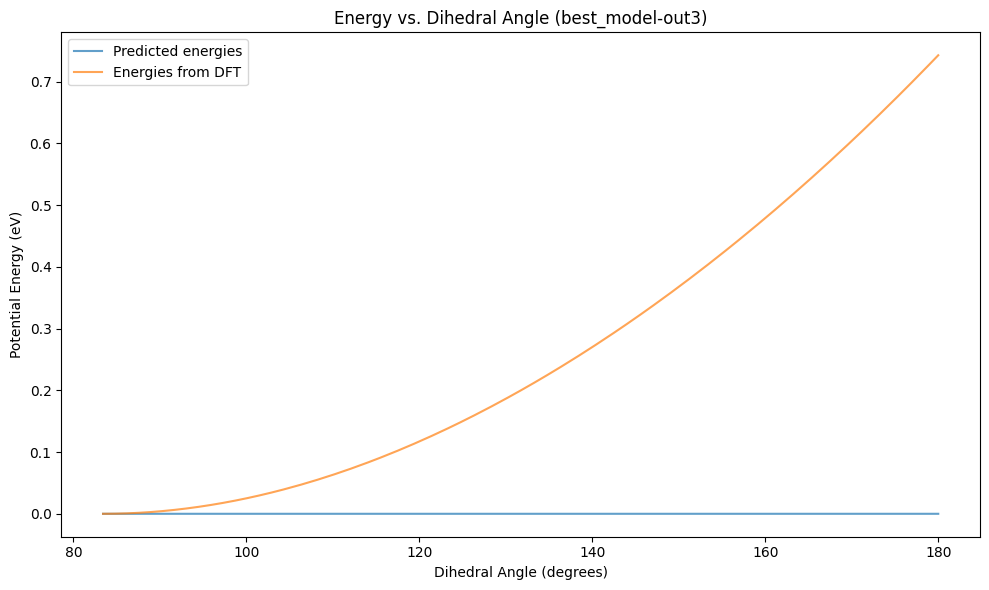

Saved: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/CACE-SOG/cumulene_dihedral_energy_curve-out3.png
Saved: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/CACE-SOG/cumulene_dihedral_energy_curve-out3.npz


In [6]:
# 1) Dihedral energy curve (results_cumulene.py equivalent)
systems_profile = read(DATASET_DIR / "cumulene_profile.xyz", index=":")
dihedrals = order_by_dihedrals(systems_profile)
actual_energies = get_energies(systems_profile)
assign_calculators(systems_profile, calculator)
predicted_energies = get_energies(systems_profile)

curve_png_path = WORKDIR / "cumulene_dihedral_energy_curve-out3.png"
curve_npz_path = WORKDIR / "cumulene_dihedral_energy_curve-out3.npz"

plot_results(
    dihedrals=dihedrals,
    predicted_energies=predicted_energies,
    actual_energies=actual_energies,
    output_path=curve_png_path,
    label="best_model-out3",
)

np.savez(
    curve_npz_path,
    dihedrals=dihedrals,
    predicted_energies=predicted_energies,
    actual_energies=actual_energies,
)

print(f"Saved: {curve_png_path}")
print(f"Saved: {curve_npz_path}")

In [7]:
# 2) Metrics on test set (metrics_cumulene.py equivalent)
systems_test = read(DATASET_DIR / "cumulene_test.xyz", index=":")

energy_reference = [system.get_potential_energy() / len(system) for system in systems_test]
forces_reference = [system.get_forces() for system in systems_test]

assign_calculators(systems_test, calculator)
energy_pred = [system.get_potential_energy() / len(system) for system in systems_test]
forces_pred = [system.get_forces() for system in systems_test]

energy_rmse = np.sqrt(mean_squared_error(energy_reference, energy_pred))
energy_mae = mean_absolute_error(energy_reference, energy_pred)

forces_reference_flat = np.concatenate(forces_reference, axis=0)
forces_pred_flat = np.concatenate(forces_pred, axis=0)
forces_rmse = np.sqrt(mean_squared_error(forces_reference_flat, forces_pred_flat))
forces_mae = mean_absolute_error(forces_reference_flat, forces_pred_flat)

print(f"Energy RMSE: {energy_rmse * 1000:.6f} meV/atom")
print(f"Energy MAE:  {energy_mae * 1000:.6f} meV/atom")
print(f"Forces RMSE: {forces_rmse * 1000:.6f} meV/A")
print(f"Forces MAE:  {forces_mae * 1000:.6f} meV/A")

metrics_path = WORKDIR / "metrics-out3.npz"
np.savez(
    metrics_path,
    energy_rmse=energy_rmse * 1000,
    energy_mae=energy_mae * 1000,
    forces_rmse=forces_rmse * 1000,
    forces_mae=forces_mae * 1000,
)
print(f"Saved: {metrics_path}")

Energy RMSE: 4952.386672 meV/atom
Energy MAE:  4952.353557 meV/atom
Forces RMSE: 157.388639 meV/A
Forces MAE:  116.801751 meV/A
Saved: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/CACE-SOG/metrics-out3.npz
